<a href="https://colab.research.google.com/github/Arthur130116/analisis_exploratorio/blob/main/3_ejercicios_pandas_delitos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis exploratorio de incidencia delictiva en México

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [16]:
!ls

sample_data


#### Ejercicio 1: Elige 3 estados de la república y grafica una serie de tiempo de la frecuencia abosluta de homicidios dolosos de enero 2015 a julio 2019 en estas tres entidades

In [24]:
# Crear carpeta data si no existe
!mkdir -p data

# Subir el archivo desde tu computadora:
# - Entra a Descargas → analisis_exploratorio-main → data
# - Selecciona el archivo delitos.csv
# - Al terminar, ejecuta esto para verificar:
!ls -la data/

total 8
drwxr-xr-x 2 root root 4096 Jun 22 05:33 .
drwxr-xr-x 1 root root 4096 Jun 22 05:33 ..


#### Ejercicio 2: Contetas las siguientes  preguntas:
1. ¿Cuántos homicidios dolosos hubo en Colima en el 2018?
2. ¿Cuantos robos de vehículo automotor ha habido en el 2019?
3. Obten la suma de homicidos dolosos y feminidios en toda la República Mexicana en cada año.
4. ¿En qué mes y en qué municipio ha ocurrido el mayor número de feminicidios?
5. ¿En qué año y en qué estado ha ocurrido el mayor número de feminicidios?

=== RESPUESTAS EJERCICIO 2 ===

1. Homicidios en Colima 2018: 726
2. Robos de vehículo en 2019: 0

3. Total por año:


,anio,frecuencia
0,2015,31744.0
1,2016,36018.0
2,2017,42068.0
3,2018,45385.0
4,2019,45822.0
5,2020,44223.0
6,2021,44960.0
7,2022,43845.0
8,2023,42846.0
9,2024,22307.0



4. Mayor cantidad: July 2020, Estado: MÃ©xico (19)
5. Mayor total: Año 2020, Estado MÃ©xico (151)

=== EJERCICIO 3: Gráficas por año ===


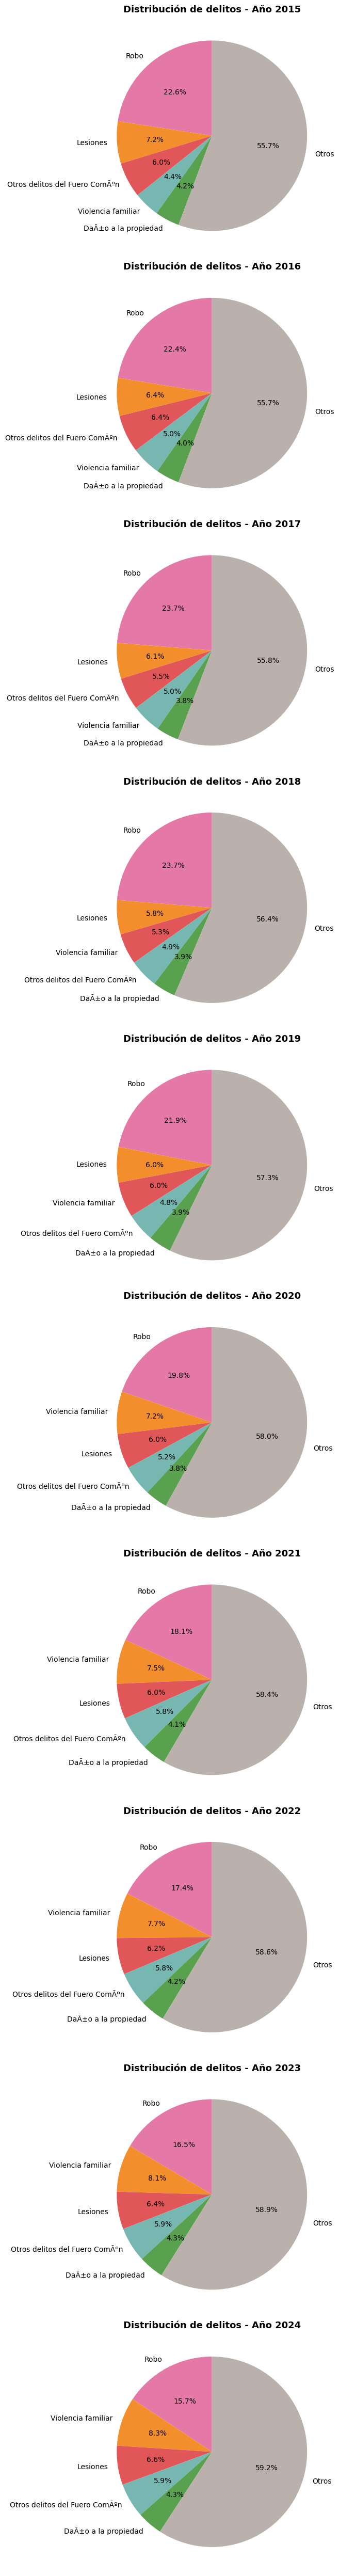

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Cargar archivo
df = pd.read_csv("delitos.csv", encoding="latin-1")

# Preparar columnas
df["fecha"] = pd.to_datetime(df["fecha"], errors="coerce")
df["anio"] = df["fecha"].dt.year

# ----------------------
# EJERCICIO 2 - RESPUESTAS
# ----------------------
print("=== RESPUESTAS EJERCICIO 2 ===\n")

# 1. Homicidios en Colima 2018
colima_2018 = df[
    (df["entidad"].str.strip() == "Colima") &
    (df["anio"] == 2018) &
    (df["tipo_de_delito"].str.strip() == "Homicidio")
]["frecuencia"].sum()
print(f"1. Homicidios en Colima 2018: {colima_2018:.0f}")

# 2. Robos de vehículo 2019
robos_2019 = df[
    (df["anio"] == 2019) &
    (df["tipo_de_delito"].str.contains("Robo de vehículo", case=False, na=False))
]["frecuencia"].sum()
print(f"2. Robos de vehículo en 2019: {robos_2019:.0f}")

# 3. Suma Homicidios + Feminicidios por año
homi_femi = df[
    df["tipo_de_delito"].str.strip().isin(["Homicidio", "Feminicidio"])
].groupby("anio")["frecuencia"].sum().reset_index()
print("\n3. Total por año:")
display(homi_femi)

# 4. Mayor feminicidios: MES y ESTADO (cambiamos municipio por entidad, ya que no existe)
feminicidios = df[df["tipo_de_delito"].str.strip() == "Feminicidio"].copy()
mayor_mes = feminicidios.loc[feminicidios["frecuencia"].idxmax()]
print(f"\n4. Mayor cantidad: {mayor_mes['fecha'].strftime('%B %Y')}, Estado: {mayor_mes['entidad']} ({mayor_mes['frecuencia']:.0f})")

# 5. Mayor total por año y estado
mayor_anio_edo = feminicidios.groupby(["anio", "entidad"])["frecuencia"].sum().reset_index()
mayor = mayor_anio_edo.loc[mayor_anio_edo["frecuencia"].idxmax()]
print(f"5. Mayor total: Año {mayor['anio']:.0f}, Estado {mayor['entidad']} ({mayor['frecuencia']:.0f})")

# ----------------------
# EJERCICIO 3 - Gráficas de pastel
# ----------------------
print("\n=== EJERCICIO 3: Gráficas por año ===")
anios = sorted(df["anio"].dropna().unique())

fig, axes = plt.subplots(nrows=len(anios), ncols=1, figsize=(10, 5*len(anios)))
axes = axes.flatten()

colores = ['#e479a7', '#f28e2b', '#e15759', '#76b7b2', '#59a14f', '#bab0ac']

for i, anio in enumerate(anios):
    datos = df[df["anio"] == anio].groupby("tipo_de_delito")["frecuencia"].sum()
    top5 = datos.nlargest(5)
    otros = pd.Series({"Otros": datos.iloc[5:].sum()})
    final = pd.concat([top5, otros])
    axes[i].pie(final, labels=final.index, autopct="%1.1f%%", startangle=90, colors=colores)
    axes[i].set_title(f"Distribución de delitos - Año {anio}", fontsize=13, weight="bold")

plt.tight_layout()
plt.show()

#### Ejercicio 3: Haz una gráfica de pastel de tipos de delito. Deberás crear una gráfica para cada año. Utilzia la función subplots de matplotlib

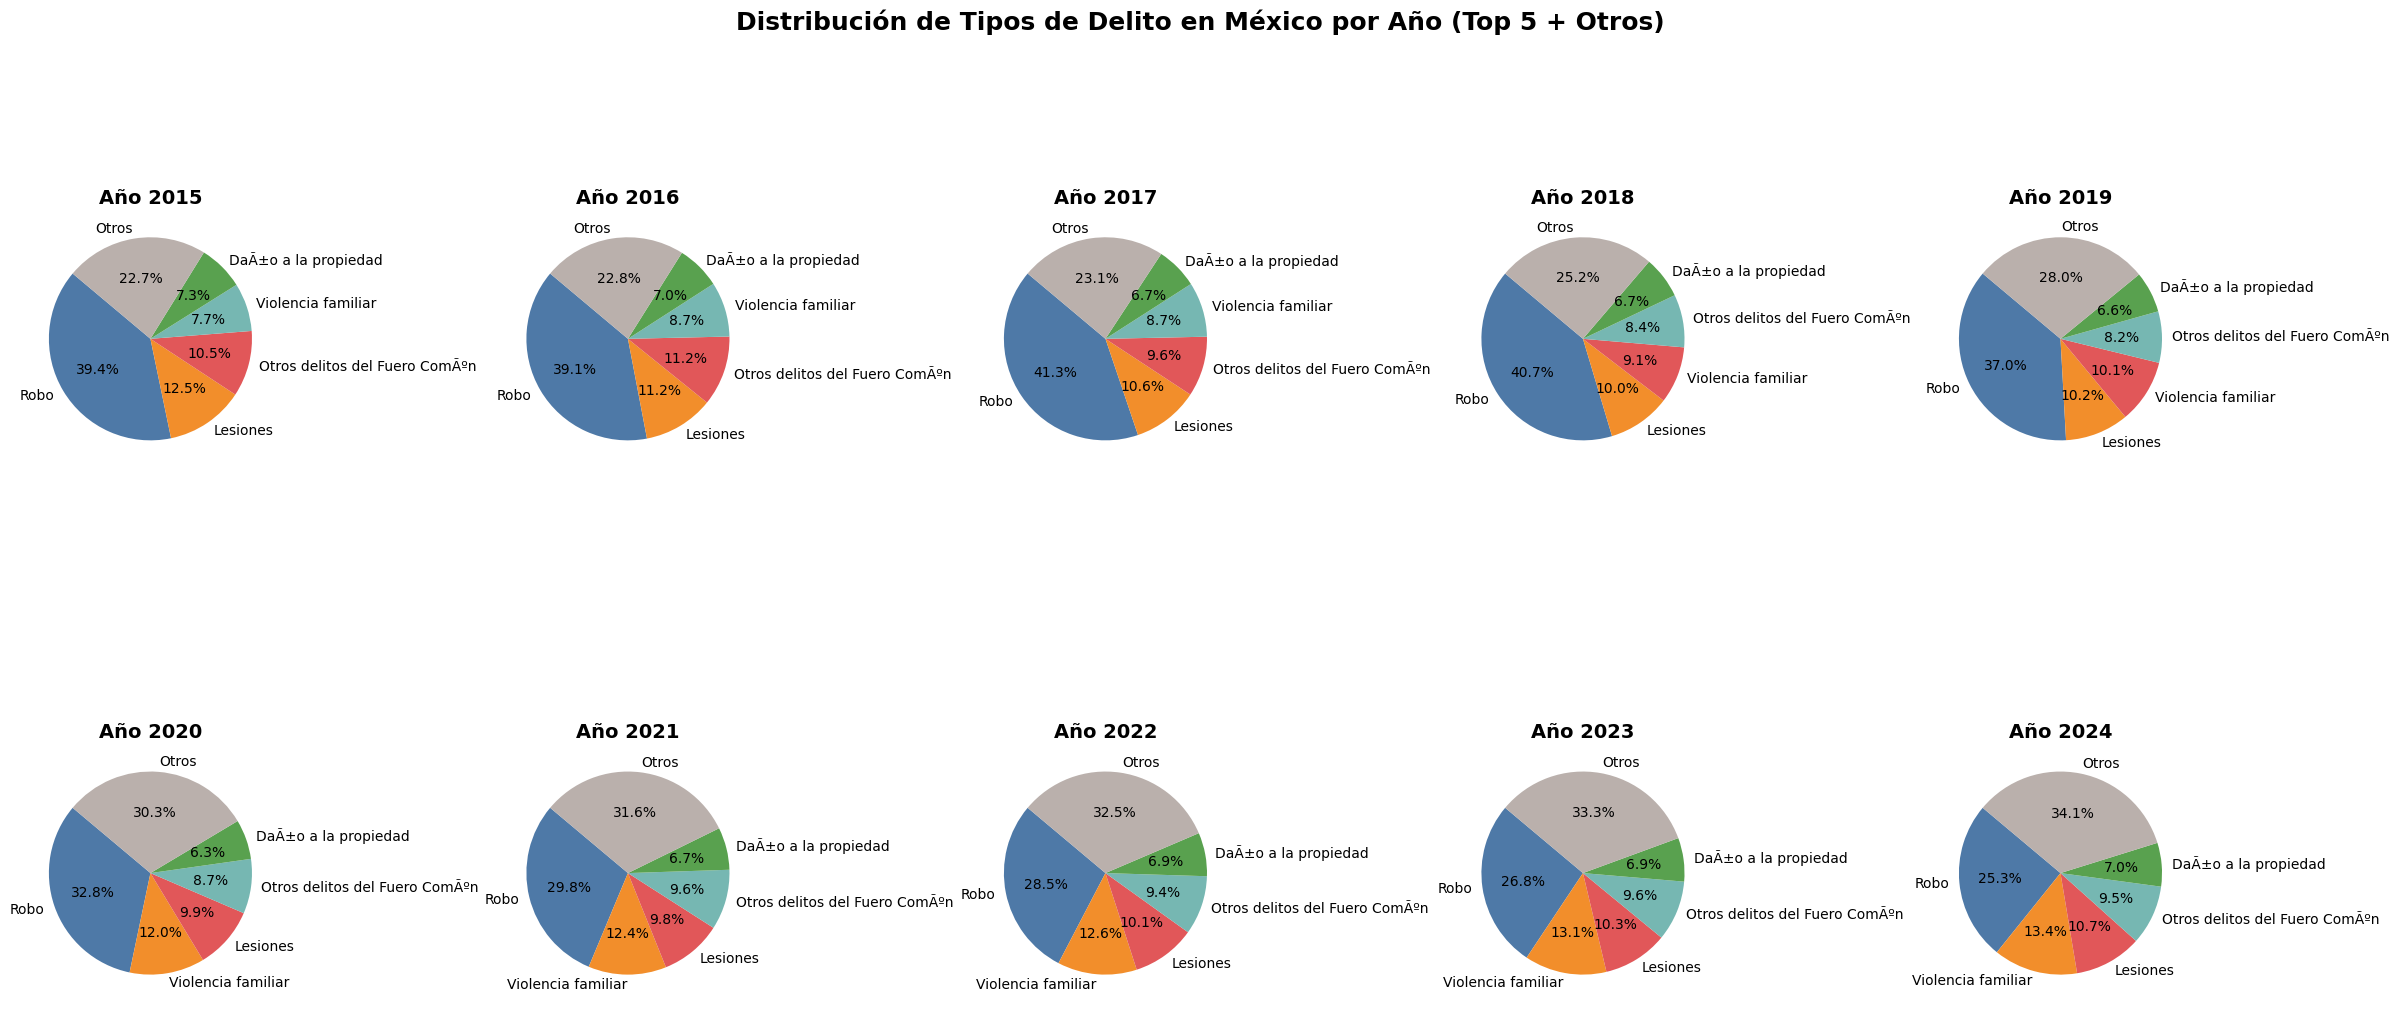

In [30]:
# Ejercicio 3: Gráfica de pastel de tipos de delito para cada año
# Agrupamos los delitos principales (Top 5) y catalogamos el resto como 'Otros' para que sea legible.
years = sorted(df['anio'].unique())

# Configurar cuadrícula de subplots
fig, axes = plt.subplots(2, 5, figsize=(24, 12))
axes = axes.flatten()

colores = ['#4e79a7', '#f28e2b', '#e15759', '#76b7b2', '#59a14f', '#bab0ac']

for i, yr in enumerate(years):
    df_yr = df[df['anio'] == yr]
    crimes_summary = df_yr.groupby('tipo_de_delito')['frecuencia'].sum().reset_index()
    crimes_summary = crimes_summary.sort_values(by='frecuencia', ascending=False)

    # Tomamos Top 5 y agrupamos el resto en 'Otros'
    top5 = crimes_summary.head(5)
    others_val = crimes_summary.iloc[5:]['frecuencia'].sum()
    others_df = pd.DataFrame([{'tipo_de_delito': 'Otros', 'frecuencia': others_val}])

    plot_data = pd.concat([top5, others_df], ignore_index=True)

    # Graficar pastel en el respectivo subplot
    axes[i].pie(
        plot_data['frecuencia'],
        labels=plot_data['tipo_de_delito'],
        autopct='%1.1f%%',
        startangle=140,
        colors=colores,
        textprops={'fontsize': 10}
    )
    axes[i].set_title(f'Año {yr}', fontsize=14, fontweight='bold')

plt.suptitle('Distribución de Tipos de Delito en México por Año (Top 5 + Otros)', fontsize=18, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()


---
#### Calcula la tasa por 100,000 habitantes
##### Tasa por 100,000 habitantes
Mostrar el total de delitos en una entidad no nos sirve de mucho. Es mucho más útil calcular la tasa de incidencia delictiva por cada 100,000 habitantes

$$
tasa = \frac{delitos\space totales}{población} \times 100,000
$$

Esta tasa la podemos anualizar multiplicándola por un factor de 12
$$
tasa\space anualizada = tasa \times 12
$$

Población por entidad federativa según [la encuesta intercensal 2015](https://www.inegi.org.mx/programas/intercensal/2015/)

No tienes que descargar nada. Ya están los datos en la carpeta data

In [33]:
!ls

data  delitos.csv  poblacion_entidades_2015.csv  sample_data


In [35]:
import pandas as pd

# Cargar archivo de población
pobs = pd.read_csv("poblacion_entidades_2015.csv", encoding="iso-8859-1", sep=";")

# Seleccionar y renombrar columnas
pobs = pobs[['Cve_Entidad', 'Entidad', 'Poblacion']]
pobs = pobs.rename(columns={'Cve_Entidad':'clave_entidad', 'Entidad':'entidad', 'Poblacion':'poblacion'})

# Verificar
pobs.head()

,clave_entidad,entidad,poblacion
0,1,Aguascalientes,1312544.0
1,2,Baja California,3315766.0
2,3,Baja California Sur,712029.0
3,4,Campeche,899931.0
4,5,Coahuila de Zaragoza,5217908.0


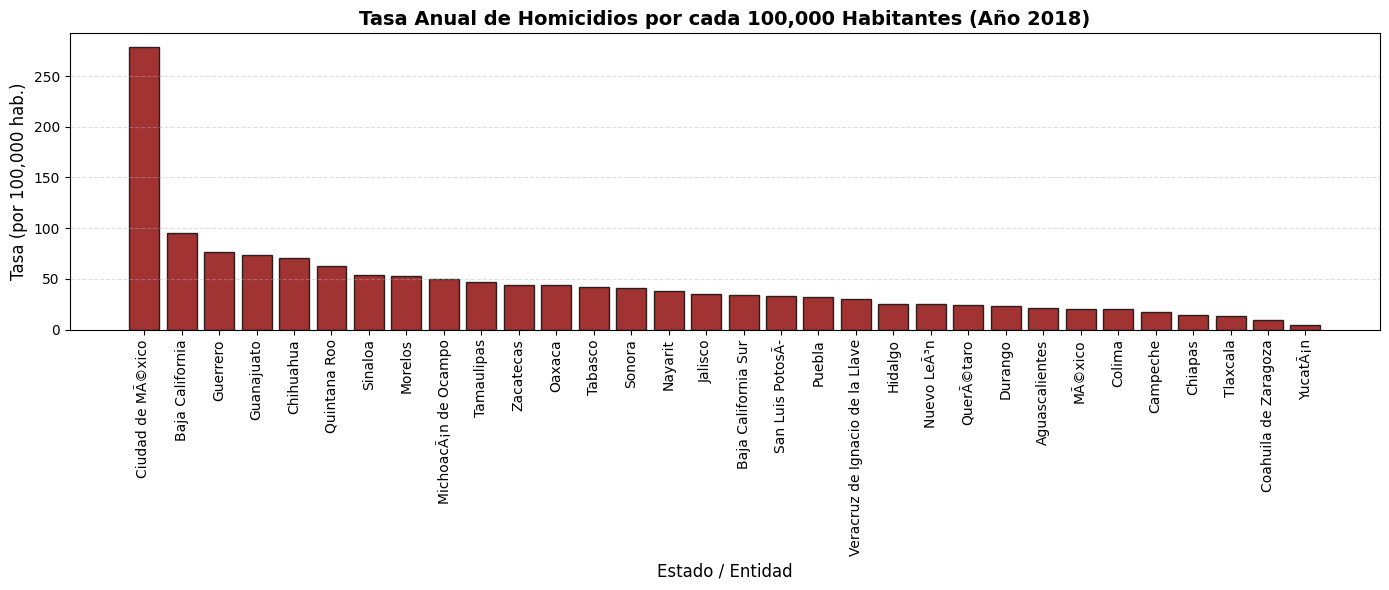

✅ Top 5 estados con mayor tasa de homicidios en 2018:


,anio,entidad,poblacion,frecuencia,tasa_anual
102,2018,Ciudad de MÃ©xico,711235.0,1979.0,278.248399
97,2018,Baja California,3315766.0,3169.0,95.573692
107,2018,Guerrero,3533251.0,2716.0,76.869716
106,2018,Guanajuato,5853677.0,4298.0,73.423935
101,2018,Chihuahua,2954915.0,2089.0,70.695773


In [37]:
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------
# 1. Cargar archivos
# ----------------------
# Delitos
df = pd.read_csv("delitos.csv", encoding="latin-1")
df["fecha"] = pd.to_datetime(df["fecha"], errors="coerce")
df["anio"] = df["fecha"].dt.year

# Población
pobs = pd.read_csv("poblacion_entidades_2015.csv", encoding="iso-8859-1", sep=";")
pobs = pobs[["Cve_Entidad", "Entidad", "Poblacion"]]
pobs = pobs.rename(columns={"Cve_Entidad":"clave_entidad", "Entidad":"entidad", "Poblacion":"poblacion"})

# ----------------------
# 2. Unir y calcular tasas
# ----------------------
df_tasas = df.merge(pobs, left_on="clave_ent", right_on="clave_entidad", how="left")
df_tasas = df_tasas.drop(columns=["clave_entidad", "entidad_y"]).rename(columns={"entidad_x":"entidad"})

# ----------------------
# 3. Análisis de homicidios 2018
# ----------------------
# Filtrar homicidios
homicidios_tasas = df_tasas[df_tasas["tipo_de_delito"].str.strip() == "Homicidio"].copy()

# Agrupar por año, estado y población
homicidios_anual = homicidios_tasas.groupby(["anio", "entidad", "poblacion"])["frecuencia"].sum().reset_index()

# Calcular tasa anual por 100 mil habitantes
homicidios_anual["tasa_anual"] = (homicidios_anual["frecuencia"] / homicidios_anual["poblacion"]) * 100000

# Filtrar año 2018 y ordenar
homicidios_2018 = homicidios_anual[homicidios_anual["anio"] == 2018].sort_values("tasa_anual", ascending=False)

# ----------------------
# 4. Gráfica
# ----------------------
plt.figure(figsize=(14, 6))
plt.bar(homicidios_2018["entidad"], homicidios_2018["tasa_anual"], color="darkred", edgecolor="black", alpha=0.8)
plt.title("Tasa Anual de Homicidios por cada 100,000 Habitantes (Año 2018)", fontsize=14, weight="bold")
plt.xlabel("Estado / Entidad", fontsize=12)
plt.ylabel("Tasa (por 100,000 hab.)", fontsize=12)
plt.xticks(rotation=90)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

# ----------------------
# 5. Mostrar Top 5
# ----------------------
print("✅ Top 5 estados con mayor tasa de homicidios en 2018:")
display(homicidios_2018.head())